# TP8 : Overfitting et validation

Importez les bibliothèques suivantes.

In [14]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Le TP précédent portait sur la régression linéaire. Le présent TP réutilisant la classe `MyRidgeRegression`, voici une cellule la définissant.

In [15]:
class MyRidgeRegression:
    def __init__(self):
        self.weights = None
        self.data = None
        self.output = None

    def fit(self, data, output, lambda_param):
        I = np.eye(data.shape[1])
        self.weights = np.linalg.inv(data.T @ data + lambda_param * I) @ data.T @ output
        self.data = data
        self.output = output

    def predict(self, data):
        return data @ self.weights

    def mse(self):
        predictions = self.predict(self.data)
        return np.mean((self.output - predictions)**2)

    def r2(self):
        predictions = self.predict(self.data)
        ss_res = np.sum((self.output - predictions)**2)
        ss_tot = np.sum((self.output - np.mean(self.output))**2)
        return 1 - (ss_res / ss_tot)

print("Classe MyRidgeRegression chargée.")

Classe MyRidgeRegression chargée.


Importez les jeux de données.

In [16]:
## from google.colab import files
## data_to_load = files.upload()
## import io
## df_prices = pd.read_csv(io.BytesIO(data_to_load['prices.csv']))

df_pixels = pd.read_csv("pixels.csv")
X = df_pixels.to_numpy(dtype="float32")
df_prices = pd.read_csv("prix.csv")
y = df_prices.values

print(f"Forme de X : {X.shape}")
print(f"Nombre de prix : {len(y)}")

Forme de X : (2535, 784)
Nombre de prix : 2535


---

## Introduction : du jeu d'entraînement au jeu de test

Dans le TP précédent, nous avons entraîné et évalué nos modèles sur le même jeu de données. Cette approche pose un problème fondamental : un modèle peut très bien mémoriser les données d'entraînement (obtenir un faible MSE sur ces données) sans pour autant avoir appris à généraliser à de nouvelles données.

Ce phénomène s'appelle le surapprentissage (overfitting). Pour l'évaluer, il faut séparer nos données en un jeu d'entraînement (pour ajuster les poids du modèle) et un jeu de test (pour évaluer sa capacité de généralisation).

L'objectif de ce TP est de comprendre l'overfitting et d'apprendre à utiliser la validation croisée pour sélectionner les hyperparamètres de manière rigoureuse.

### Reproductibilité et graines aléatoires (seeds)

Le découpage train/test est aléatoire. Pour garantir la reproductibilité des résultats (obtenir les mêmes découpages à chaque exécution), on utilise une graine aléatoire (seed). La fonction `np.random.seed(valeur)` initialise le générateur de nombres aléatoires de NumPy avec une valeur fixe. Deux exécutions avec le même seed produiront exactement les mêmes nombres aléatoires, donc le même découpage.

Dans ce TP, nous explorerons également l'impact du choix du seed sur la stabilité des modèles. Un modèle robuste devrait donner des performances similaires quel que soit le découpage aléatoire des données.

## Exercice 1

1. Créez une fonction `train_test_split(data, labels, train_ratio=0.8, seed=42)` qui prend en entrée `data` et `labels`, mélange les indices avec `np.random.permutation` (**[documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html)**) après avoir fixé le seed avec `np.random.seed(seed)`, découpe selon `train_ratio`, et retourne `data_train`, `data_test`, `labels_train`, `labels_test`. Testez cette fonction en affichant les dimensions des ensembles retournés.

In [ ]:
def train_test_split(data, labels, train_ratio=0.8, seed=42):
    np.random.seed(seed)
    #  indices
    indices = np.random.permutation(len(data))
    split_point = int(len(data) * train_ratio)
    train_indices = indices[:split_point]
    test_indices = indices[split_point:]
    
    # div data et labels
    data_train = data[train_indices]
    data_test = data[test_indices]
    labels_train = labels[train_indices]
    labels_test = labels[test_indices]
    
    return data_train, data_test, labels_train, labels_test

# Test
data_train, data_test, labels_train, labels_test = train_test_split(X, y, train_ratio=0.8, seed=42)
print(f"Dimensions de data_train : {data_train.shape}")
print(f"Dimensions de data_test : {data_test.shape}")
print(f"Dimensions de labels_train : {labels_train.shape}")
print(f"Dimensions de labels_test : {labels_test.shape}")

Dimensions de data_train : (2028, 784)
Dimensions de data_test : (507, 784)
Dimensions de labels_train : (2028, 1)
Dimensions de labels_test : (507, 1)


2. Pour étudier la stabilité du modèle, testez plusieurs découpages différents en variant le seed. Pour chacun des seeds suivants : `42`, `123`, `456`, `789`, `101`, `202`, `303`, `404`, `505`, `606`, créez un découpage train/test, entraînez un modèle Ridge avec `lambda = 1.0`, et stockez le MSE test. Affichez ensuite la moyenne et l'écart-type des MSE test obtenus. Refaites la même chose avec `lambda = 1000`. Affichez les résultats sous forme de tableau comparatif.

In [18]:
# Seeds demandés
seeds = [42, 123, 456, 789, 101, 202, 303, 404, 505, 606]
lambda_values = [1.0, 1000.0]
# Calcul pour chaque (seed, lambda)
results = []
for lambda_param in lambda_values:
    for seed in seeds:
        data_train_s, data_test_s, labels_train_s, labels_test_s = train_test_split(
            X, y, train_ratio=0.8, seed=seed
        )
        model = MyRidgeRegression()
        model.fit(data_train_s, labels_train_s, lambda_param=lambda_param)

        y_pred_test = model.predict(data_test_s)
        mse_test = np.mean((labels_test_s-y_pred_test) ** 2)

        results.append({
            "lambda": lambda_param,
            "seed": seed,
            "mse_test": float(mse_test)
                                        })
df_mse = pd.DataFrame(results)
# Tableau
table_detail = df_mse.pivot(index="seed", columns="lambda", values="mse_test")
print("MSE test par seed :")
print(table_detail)

# Tableau comparatif
table_comparatif = (
    df_mse.groupby("lambda")["mse_test"]
    .agg(moyenne_mse_test="mean", ecart_type_mse_test="std")
    .reset_index()
    .sort_values("lambda")
)

print("\nTableau comparatif :")
print(table_comparatif)

MSE test par seed :
lambda         1.0          1000.0
seed                              
42       54641.055945   643.959201
101      13976.279763   682.776634
123      36025.535142  1251.499001
202     137413.155228   690.706105
303      27339.649319   892.962350
404      60410.702511   876.664244
456      16410.087801   732.590130
505      18319.958438   752.032163
606      56661.215958   813.547214
789      33846.591039  1011.729838

Tableau comparatif :
   lambda  moyenne_mse_test  ecart_type_mse_test
0     1.0      45504.423114         36533.967381
1  1000.0        834.846688           185.028855


3. Que constatez-vous sur la variabilité des résultats entre les deux valeurs de $\lambda$ ? Quel est le rôle de la régularisation par rapport à la stabilité du modèle ?

On observe une très grande variabilité avec lambda = 1:les MSE test changent énormément selon le seed (écart-type très élevé, ~36 534, avec une moyenne ~45 504).  
À l’inverse, avec lambda = 1000, les résultats sont beaucoup plus stables (moyenne ~835, écart-type ~185), et globalement bien meilleurs.

Donc, la régularisation joue un rôle de stabilisateur, en augmentant lambda, on contraint les poids du modèle, ce qui limite le surapprentissage au jeu d’entraînement. Le modèle devient moins sensible au découpage aléatoire (seed), donc il généralise mieux.

4. Les courbes d'apprentissage permettent de visualiser comment les performances évoluent en fonction de la taille du jeu d'entraînement. Pour différentes tailles de jeu d'entraînement (30%, 40%, 50%, 60%, 70%, 80%, 90%, 100% des données d'entraînement), entraînez un modèle Ridge avec `lambda = 1000` et calculez le MSE train et le MSE test. Tracez deux courbes sur le même graphique : MSE train en fonction de la taille et MSE test en fonction de la taille. Testez plusieurs seeds.

C:\Users\TRETEC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\TRETEC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


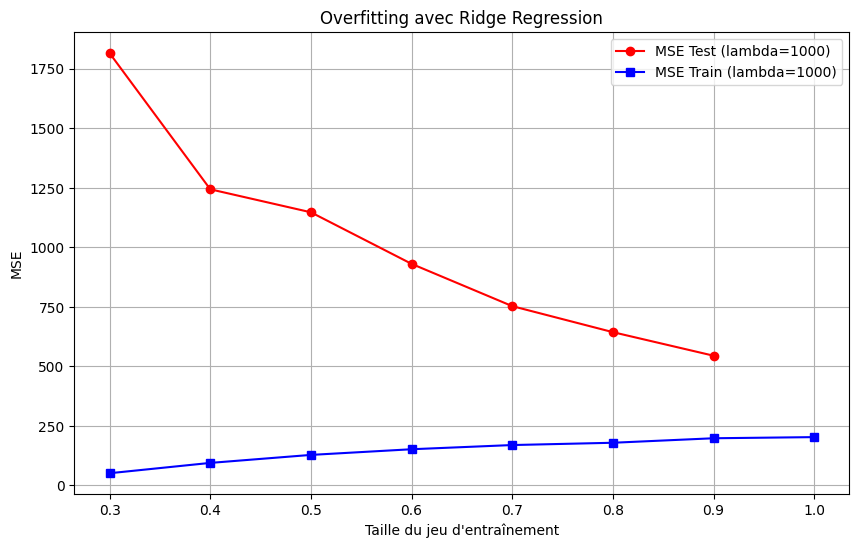

In [19]:
taille_jeu=[0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
mse_test_1000=[]
mse_train_1000=[]

for taille in taille_jeu:
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X, y, train_ratio=taille, seed=42)
    
    model=MyRidgeRegression()
    model.fit(X_train_temp, y_train_temp, lambda_param=1000.0)
    
    pred_test = model.predict(X_test_temp)
    pred_train = model.predict(X_train_temp)
    
    mse_test = np.mean((y_test_temp - pred_test)**2)
    mse_train = np.mean((y_train_temp - pred_train)**2)
    
    mse_test_1000.append(mse_test)
    mse_train_1000.append(mse_train)
plt.figure(figsize=(10, 6))
plt.plot(taille_jeu, mse_test_1000, marker='o', label='MSE Test (lambda=1000)', color='red')
plt.plot(taille_jeu, mse_train_1000, marker='s', label='MSE Train (lambda=1000)', color='blue')
plt.xlabel('Taille du jeu d\'entraînement')
plt.ylabel('MSE')
plt.title('Overfitting avec Ridge Regression')
plt.legend()
plt.grid(True)
plt.show()

5. Que constatez-vous sur l'évolution du MSE train et du MSE test en fonction de la taille du jeu d'entraînement ? Comment l'écart entre les deux courbes évolue-t-il ?

Globalement, on voit un comportement assez classique :

Quand la taille du jeu d’entraînement augmente, le MSE train augmente progressivement (le modèle “mémorise” moins facilement un grand jeu).
En parallèle, le MSE test diminue nettement

Au début (petites tailles), il y a un grand écart entre train et test : c’est une zone plus sujette au surapprentissage.  
Puis, en ajoutant des données, les deux courbes se rapprochent , l’écart train/test diminue, ce qui indique un modèle plus stable et plus robuste.  

On remarque aussi que la variabilité entre seeds est plus forte pour les petites tailles, puis devient plus raisonnable quand on se rapproche de 100% du train.

## Exercice 2

Le paramètre de régularisation $\lambda$ contrôle la complexité du modèle. Un $\lambda$ trop petit peut conduire à l'overfitting (le modèle mémorise le bruit des données d'entraînement), tandis qu'un $\lambda$ trop grand peut conduire à l'underfitting (le modèle est trop simple pour capturer les patterns).

1. Pour différentes valeurs de `lambda` (`0.1`, `1`, `10`, `100`, `1000`, `10000`, `100000`, `1000000`, `10000000`, `100000000`, `1000000000`), entraînez un modèle Ridge sur le jeu d'entraînement complet et calculez le MSE train et le MSE test. Tracez les deux courbes sur le même graphique (échelle logarithmique pour les deux axes). Note : nous travaillons avec 784 paramètres, ce qui explique que les valeurs optimales de $\lambda$ sont très grandes.

          lambda   mse_train       mse_test
0   1.000000e-01  157.883714  444018.654756
1   1.000000e+00  161.099191   54641.055945
2   1.000000e+01  166.892664    3179.231466
3   1.000000e+02  172.329323    1260.781923
4   1.000000e+03  179.318757     643.959201
5   1.000000e+04  190.809335     542.392617
6   1.000000e+05  213.733430     458.956697
7   1.000000e+06  266.430890     398.306071
8   1.000000e+07  343.439951     410.746788
9   1.000000e+08  452.864590     496.802999
10  1.000000e+09  650.702527     656.667815


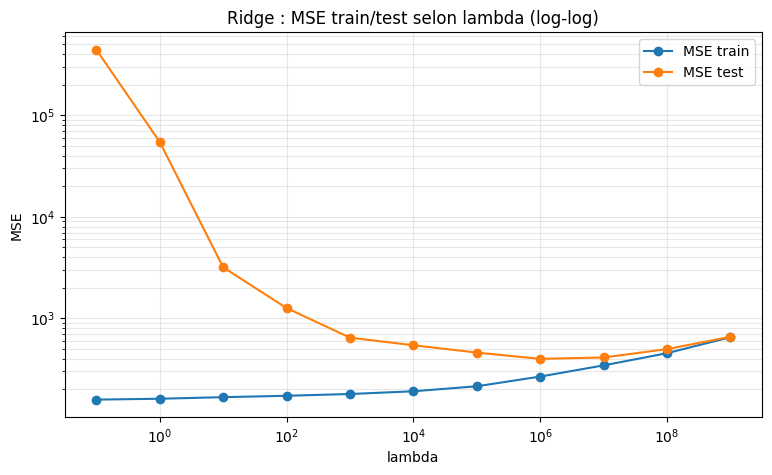

In [20]:
lambda_grid = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_ratio=0.8, seed=42)

ridge_results = []
for lam in lambda_grid:
    model = MyRidgeRegression()
    model.fit(X_train, y_train, lambda_param=lam)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    mse_train = float(np.mean((y_train - y_pred_train) ** 2))
    mse_test = float(np.mean((y_test - y_pred_test) ** 2))

    ridge_results.append({
        "lambda": lam,
        "mse_train": mse_train,
        "mse_test": mse_test
    })

df_ridge = pd.DataFrame(ridge_results)
print(df_ridge)

plt.figure(figsize=(9, 5))
plt.plot(df_ridge["lambda"], df_ridge["mse_train"], marker="o", label="MSE train")
plt.plot(df_ridge["lambda"], df_ridge["mse_test"], marker="o", label="MSE test")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("lambda")
plt.ylabel("MSE")
plt.title("Ridge : MSE train/test selon lambda (log-log)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

2. Identifiez la zone d'overfitting (petit $\lambda$) et la zone d'underfitting (grand $\lambda$). Quelle valeur de $\lambda$ minimise le MSE test ? Est-ce la même qui minimise le MSE train ?

On voit clairement deux zones :

1)- à gauche(gamma petit): le mse test est très haut contrairement au mse train qui est tres bas , donc le modèle mémorise les données et généralise mal (overffitting)

2)- à droite(gamma grand):À droite, les deux courbes se rejoignent et remontent. Le modèle est contraint et n'apprend plus grand.c'est l'underfitting.

La valeur qui minimise le MSE test est ici lambda = 10^6 (MSE test approximat 398.31).  

Non, ce n’est pas la même qui minimise le MSE train, le plus petit MSE train est pour lambda = 0.1 (\(\approx 157.88\)).  

Donc le meilleur compromis de généralisation est autour de 10^6, pas là où l’erreur d’entraînement est minimale.

## Exercice 3

L'exercice précédent pose un problème : nous avons utilisé le jeu de test pour choisir le meilleur $\lambda$. Or, le jeu de test doit rester "vierge" et ne servir qu'à l'évaluation finale du modèle. Si on l'utilise pour sélectionner les hyperparamètres, on risque de surajuster sur ce jeu de test.

La solution est la validation croisée (cross-validation). L'idée est de découper le jeu d'entraînement en k sous-ensembles (folds), d'entraîner k modèles (chacun sur k-1 folds et testé sur le fold restant), puis de moyenner les performances.

1. Construisez une fonction `cross_validate(data, labels, k_folds, lambda_param)` qui découpe `data` et `labels` en `k_folds` parties égales, entraîne `k` modèles Ridge avec le paramètre `lambda_param` donné, et retourne la moyenne des MSE obtenus sur chaque fold de validation. Utilisez cette fonction pour tester `k_folds = 5` avec `lambda_param = 10000`.

In [21]:
def cross_validate(data, labels, k_folds, lambda_param):
    n_samples = data.shape[0]
    fold_size = n_samples // k_folds
    mse_scores = []
    
    for i in range(k_folds):
        val_start = i * fold_size
        val_end = val_start + fold_size if i < k_folds - 1 else n_samples
        
        val_indices = np.arange(val_start, val_end)
        train_indices = np.concatenate([np.arange(0, val_start), np.arange(val_end, n_samples)])
        
        X_train_fold = data[train_indices]
        y_train_fold = labels[train_indices]
        X_val_fold = data[val_indices]
        y_val_fold = labels[val_indices]
        
        model = MyRidgeRegression()
        model.fit(X_train_fold, y_train_fold, lambda_param=lambda_param)
        
        y_pred_val = model.predict(X_val_fold)
        mse = np.mean((y_val_fold - y_pred_val) ** 2)
        mse_scores.append(float(mse))
    return np.mean(mse_scores)

# test
cv_score = cross_validate(X_train, y_train, k_folds=5, lambda_param=10000)
print(f"Cross-validation MSE (k=5, lambda=10000): {cv_score:.2f}")

Cross-validation MSE (k=5, lambda=10000): 648.48


2. Utilisez la validation croisée pour sélectionner le meilleur $\lambda$ parmi les valeurs testées précédemment. Pour chaque valeur, calculez le MSE cross-validation. Affichez les résultats et identifiez le meilleur $\lambda$.

Résultats de la validation croisée :
          lambda         cv_mse
0   1.000000e-01  321194.999025
1   1.000000e+00   51754.406297
2   1.000000e+01    7986.419666
3   1.000000e+02    1920.377681
4   1.000000e+03     967.074862
5   1.000000e+04     648.477099
6   1.000000e+05     464.316877
7   1.000000e+06     380.677781
8   1.000000e+07     387.284535
9   1.000000e+08     475.114446
10  1.000000e+09     697.038236

Meilleur lambda par validation croisée : 1000000.0
CV MSE correspondant : 380.68

Meilleur lambda par MSE test (exercice 2) : 1000000.0
MSE test correspondant : 398.31


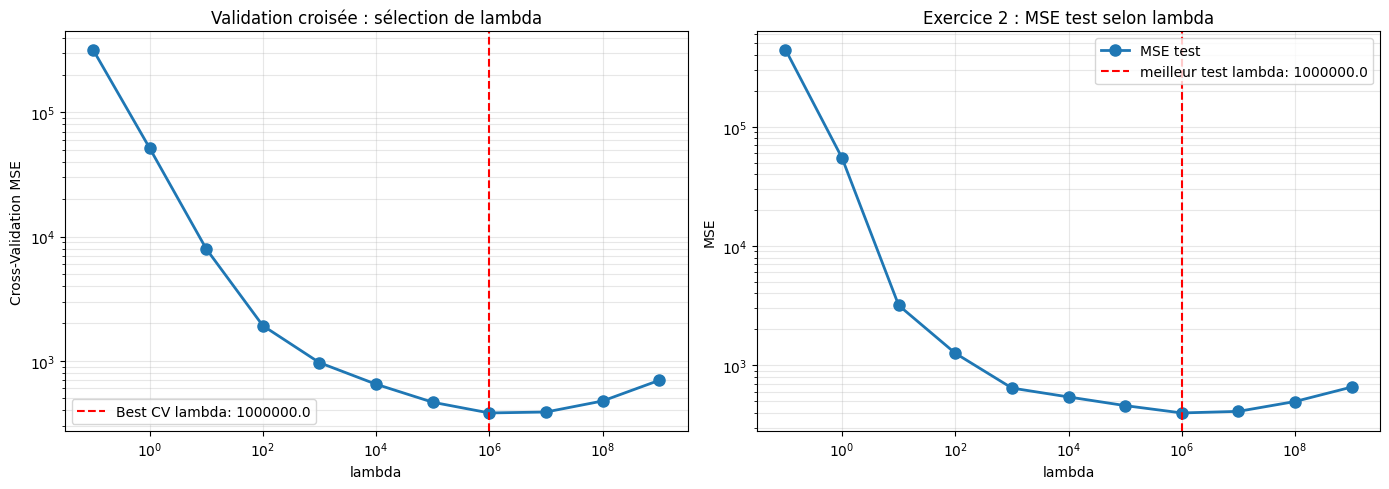

In [22]:
cv_scores = []
for lam in lambda_grid:
    cv_mse = cross_validate(X_train, y_train, k_folds=5, lambda_param=lam)
    cv_scores.append({
        "lambda": lam,
        "cv_mse": float(cv_mse)
    })

df_cv = pd.DataFrame(cv_scores)
print("Résultats de la validation croisée :")
print(df_cv)

best_lambda_cv = df_cv.loc[df_cv["cv_mse"].idxmin(), "lambda"]
best_cv_mse = df_cv["cv_mse"].min()

print(f"\nMeilleur lambda par validation croisée : {best_lambda_cv}")
print(f"CV MSE correspondant : {best_cv_mse:.2f}")

# Comparaison avec l'exercice 2
best_lambda_test = df_ridge.loc[df_ridge["mse_test"].idxmin(), "lambda"]
best_test_mse = df_ridge["mse_test"].min()

print(f"\nMeilleur lambda par MSE test (exercice 2) : {best_lambda_test}")
print(f"MSE test correspondant : {best_test_mse:.2f}")

# visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_cv["lambda"], df_cv["cv_mse"], marker="o", linewidth=2, markersize=8)
ax1.axvline(best_lambda_cv, color="r", linestyle="--", label=f"Best CV lambda: {best_lambda_cv}")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("lambda")
ax1.set_ylabel("Cross-Validation MSE")
ax1.set_title("Validation croisée : sélection de lambda")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

ax2.plot(df_ridge["lambda"], df_ridge["mse_test"], marker="o", linewidth=2, markersize=8, label="MSE test")
ax2.axvline(best_lambda_test, color="r", linestyle="--", label=f"meilleur test lambda: {best_lambda_test}")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("lambda")
ax2.set_ylabel("MSE")
ax2.set_title("Exercice 2 : MSE test selon lambda")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()
## le meilleur lambda est celui qui minimise le MSE de la validation croisée, dans ce cas c'est  10puissance 6

3. Comparez le $\lambda$ sélectionné par validation croisée avec celui qui minimisait le MSE test dans l'exercice 2. Sont-ils identiques ? Même si les performances finales sont similaires, expliquez pourquoi la méthode par validation croisée est méthodologiquement supérieure.

Globalement, le lambdachoisi par validation croisée peut être proche de celui qui minimisait le MSE test à l’exercice 2, mais il n’est pas forcément exactement identique. C’est normal, parce que les deux méthodes n’utilisent pas la même logique de sélection.

La différence importante, c’est surtout la méthode :

- Dans l’exercice 2, on choisit lambda avec le jeu de test => on “regarde” le test pour décider, donc on biaise un peu l’évaluation finale.  
- Avec la validation croisée, on choisit lambda uniquement à partir du jeu d’entraînement (découpé en folds), puis on garde le test pour la toute fin.

Du coup, la validation croisée est méthodologiquement meilleure, car elle donne une sélection d’hyperparamètre plus robuste et évite de surajuster le choix de lambda au jeu de test. Même si les performances finales se ressemblent, la démarche est plus correcte scientifiquement.

## Exercice 4 (Bonus)

1. Que se passe-t-il quand $\lambda$ devient très grand (tend vers l'infini) dans la formule Ridge : $\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$ ? Vers quelle valeur tendent les poids ?

Pour des gamma très grands, l'expression (X^T X + lambda I)^-1 est dominée par gamma * I.
w = X^T * y / gamma → 0

2. Entraînez deux modèles Ridge sur le jeu d'entraînement : un avec $\lambda = 1$ et un avec $\lambda = 10^{15}$ (régularisation extrême). Pour chaque modèle, calculez le MSE test, affichez les 10 premières prédictions avec les vraies valeurs correspondantes, ainsi que le minimum et le maximum des prédictions. Que constatez-vous sur le comportement des deux modèles ?

In [23]:
lambdas_to_test = [1.0, 1e15]
model_results = {}

for lam in lambdas_to_test:
    model = MyRidgeRegression()
    model.fit(X_train, y_train, lambda_param=lam)

    y_pred_test = model.predict(X_test)
    mse_test = float(np.mean((y_test - y_pred_test) ** 2))

    model_results[lam] = {
        "model": model,
        "y_pred_test": y_pred_test,
        "mse_test": mse_test,
        "pred_min": float(np.min(y_pred_test)),
        "pred_max": float(np.max(y_pred_test)),
    }

# tableau recapitulatif
df_compare = pd.DataFrame(
    [
        {
            "lambda": lam,
            "mse_test": model_results[lam]["mse_test"],
            "pred_min": model_results[lam]["pred_min"],
            "pred_max": model_results[lam]["pred_max"],
            "pred_range": model_results[lam]["pred_max"] - model_results[lam]["pred_min"],
        }
        for lam in lambdas_to_test
    ]
).sort_values("lambda")

print("Résumé des performances :")
print(df_compare.to_string(index=False))

# Affichage détaillé des 10 prem
for lam in lambdas_to_test:
    y_pred = model_results[lam]["y_pred_test"].ravel()
    y_true = y_test.ravel()

    print(f"\n--- Lambda = {lam:.0e} ---")
    print(f"MSE test      : {model_results[lam]['mse_test']:.4f}")
    print(f"Min prédiction: {model_results[lam]['pred_min']:.4f}")
    print(f"Max prédiction: {model_results[lam]['pred_max']:.4f}")
    print("10 premières prédictions vs vraies valeurs :")

    df_first10 = pd.DataFrame({
        "y_true": y_true[:10],
        "y_pred": y_pred[:10],
        "erreur_abs": np.abs(y_true[:10] - y_pred[:10]),
    })
    print(df_first10.to_string(index=False))

Résumé des performances :
      lambda     mse_test    pred_min    pred_max  pred_range
1.000000e+00 54641.055945 -947.458112 5079.711877 6027.169989
1.000000e+15  8692.472980    0.000222    0.002288    0.002067

--- Lambda = 1e+00 ---
MSE test      : 54641.0559
Min prédiction: -947.4581
Max prédiction: 5079.7119
10 premières prédictions vs vraies valeurs :
 y_true     y_pred  erreur_abs
  76.49  70.367027    6.122973
 143.81 230.419660   86.609660
  91.99 135.099149   43.109149
 160.26 161.417472    1.157472
 131.40 117.352668   14.047332
 139.56 178.069147   38.509147
  50.00  55.817508    5.817508
  66.93  99.235891   32.305891
  60.45  60.187750    0.262250
 110.32 125.863416   15.543416

--- Lambda = 1e+15 ---
MSE test      : 8692.4730
Min prédiction: 0.0002
Max prédiction: 0.0023
10 premières prédictions vs vraies valeurs :
 y_true   y_pred  erreur_abs
  76.49 0.001443   76.488557
 143.81 0.002024  143.807976
  91.99 0.001721   91.988279
 160.26 0.001766  160.258234
 131.40 0.001

3. D'après vos observations, le MSE seul est-il une métrique suffisante pour détecter ce type de problème ? Proposez une approche ou une métrique complémentaire qui permettrait d'identifier qu'un modèle ne fait rien d'utile. Implémentez cette métrique pour les deux modèles ($\lambda = 1$ et $\lambda = 10^{15}$) et comparez avec un modèle Ridge ayant un $\lambda$ optimal (celui trouvé dans l'exercice 3).

In [24]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

pred1 = model_results[1.0]["y_pred_test"].flatten()
pred2 = model_results[1e15]["y_pred_test"].flatten()

mse_test_1 = model_results[1.0]["mse_test"]
mse_test_2 = model_results[1e15]["mse_test"]

r2_lambda_1 = r2_score(y_test.flatten(), pred1)
r2_lambda_2 = r2_score(y_test.flatten(), pred2)

model_opt = MyRidgeRegression()
model_opt.fit(X_train, y_train, lambda_param=10**6)
pred_opt = model_opt.predict(X_test).flatten()
mse_opt = np.mean((y_test - pred_opt)**2)
r2_lambda_opt = r2_score(y_test.flatten(), pred_opt)

print(f"{'Modèle':<15} {'MSE':>12} {'R²':>10}")
print("-" * 40)
print(f"{'λ=1':<15} {mse_test_1:>12.2f} {r2_lambda_1:>10.4f}")
print(f"{'λ=1e15':<15} {mse_test_2:>12.2f} {r2_lambda_2:>10.4f}")
print(f"{'λ=1e6 (opt)':<15} {mse_opt:>12.2f} {r2_lambda_opt:>10.4f}")


Modèle                   MSE         R²
----------------------------------------
λ=1                 54641.06   -45.1192
λ=1e15               8692.47    -6.3368
λ=1e6 (opt)          2593.73     0.6638


l'autre métrique (tp précédent, le R2_score)